# UK NHS Dataset Modeling

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

### Reading the Dataset

In [2]:
data = pd.read_csv("dataset/Hospital.csv")
data.head(10)

,OrganisationID,OrganisationCode,OrganisationType,SubType,Sector,OrganisationStatus,IsPimsManaged,OrganisationName,Address1,Address2,...,County,Postcode,Latitude,Longitude,ParentODSCode,ParentName,Phone,Email,Website,"Fax,,,"
0,17970,NDA07,Hospital,Hospital,Independent Sector,Visible,True,Walton Community Hospital - Virgin Care Servic...,NaN,Rodney Road,...,Surrey,KT12 3LD,51.379997,-0.406042,NDA,Virgin Care Services Ltd,01932 414205,NaN,NaN,"01932 253674,,,"
1,17981,NDA18,Hospital,Hospital,Independent Sector,Visible,True,Woking Community Hospital (Virgin Care),NaN,Heathside Road,...,Surrey,GU22 7HS,51.315132,-0.556289,NDA,Virgin Care Services Ltd,01483 715911,NaN,NaN,",,,"
2,18102,NLT02,Hospital,Hospital,NHS Sector,Visible,True,North Somerset Community Hospital,North Somerset Community Hospital,Old Street,...,Avon,BS21 6BS,51.437195,-2.847193,NLT,North Somerset Community Partnership Community...,01275 872212,NaN,http://www.nscphealth.co.uk,",,,"
3,18138,NMP01,Hospital,Hospital,Independent Sector,Visible,False,Bridgewater Hospital,120 Princess Road,NaN,...,Greater Manchester,M15 5AT,53.459743,-2.245469,NMP,Bridgewater Hospital (Manchester) Ltd,0161 2270000,NaN,www.bridgewaterhospital.com,",,,"
4,18142,NMV01,Hospital,Hospital,Independent Sector,Visible,True,Kneesworth House,Old North Road,Bassingbourn,...,NaN,SG8 5JP,52.078121,-0.030604,NMV,Partnerships In Care Ltd,01763 255 700,reception_kneesworthhouse@partnershipsincare.c...,www.partnershipsincare.co.uk,",,,"
5,18143,NMV02,Hospital,Hospital,Independent Sector,Visible,True,Stockton Hall Hospital,Stockton Hall,The Village,...,North Yorkshire,YO32 9UN,53.995403,-1.002553,NMV,Partnerships In Care Ltd,01904 400 500,info@priorygroup.com,https://www.priorygroup.com/stockton-hall,",,,"
6,18271,NQ106,Hospital,Hospital,Independent Sector,Visible,True,"Fryatt Hospital, Harwich",419 Main Road,NaN,...,Essex,CO12 4EX,51.934696,1.261444,NQ1,Anglian Community Enterprise Community Interes...,01255 201200,NaN,NaN,",,"
7,18272,NQ108,Hospital,Hospital,Independent Sector,Visible,True,Clacton Hospital,NaN,Tower Road,...,Essex,CO15 1LH,51.786079,1.148188,NQ1,Anglian Community Enterprise Community Interes...,01255 201717,NaN,https://www.esneft.nhs.uk/your-visit/our-wards...,"01206 286710,,,"
8,18289,NQ901,Hospital,Hospital,Independent Sector,Visible,False,Lakeside Hospital,The Lane,Wyboston,...,Bedfordshire,MK44 3AS,52.198326,-0.310281,NQ9,Brookdale Healthcare Ltd (T/A Brookdale Care),NaN,NaN,NaN,",,,"
9,18305,NQM01,Hospital,Hospital,Independent Sector,Visible,True,Orthopaedics and Spine Specialist Hospital,1 Stirling Way,Bretton,...,Cambridgeshire,PE3 8YA,52.604942,-0.283022,NQM,Orthopaedics and Spine Specialist Hospital,01733 333156,info@orthospine.co.uk,NaN,"01733 373050,,,"


### Understanding the dataset

In [3]:
data.columns

Index(['OrganisationID', 'OrganisationCode', 'OrganisationType', 'SubType',
       'Sector', 'OrganisationStatus', 'IsPimsManaged', 'OrganisationName',
       'Address1', 'Address2', 'Address3', 'City', 'County', 'Postcode',
       'Latitude', 'Longitude', 'ParentODSCode', 'ParentName', 'Phone',
       'Email', 'Website', 'Fax,,,'],
      dtype='object')

### Check the datatypes

In [4]:
data.dtypes

OrganisationID          int64
OrganisationCode       object
OrganisationType       object
SubType                object
Sector                 object
OrganisationStatus     object
IsPimsManaged            bool
OrganisationName       object
Address1               object
Address2               object
Address3               object
City                   object
County                 object
Postcode               object
Latitude              float64
Longitude             float64
ParentODSCode          object
ParentName             object
Phone                  object
Email                  object
Website                object
Fax,,,                 object
dtype: object

### Shape of Dataset

In [5]:
print('UK NHS dataset shape:',data.shape)

UK NHS dataset shape: (1211, 22)


### Dataset info

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1211 entries, 0 to 1210
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OrganisationID      1211 non-null   int64  
 1   OrganisationCode    1211 non-null   object 
 2   OrganisationType    1211 non-null   object 
 3   SubType             1211 non-null   object 
 4   Sector              1211 non-null   object 
 5   OrganisationStatus  1211 non-null   object 
 6   IsPimsManaged       1211 non-null   bool   
 7   OrganisationName    1211 non-null   object 
 8   Address1            883 non-null    object 
 9   Address2            727 non-null    object 
 10  Address3            147 non-null    object 
 11  City                1196 non-null   object 
 12  County              973 non-null    object 
 13  Postcode            1210 non-null   object 
 14  Latitude            1209 non-null   float64
 15  Longitude           1209 non-null   float64
 16  ParentODSCo

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
OrganisationID,1211.0,1.375611e+06,3.024986e+06,17970.000000,40649.000000,43110.000000,76107.000000,1.095615e+07
Latitude,1209.0,5.231751e+01,1.213026e+00,49.913063,51.410404,52.038059,53.378357,5.577329e+01
Longitude,1209.0,-1.293855e+00,1.294781e+00,-6.309277,-2.154729,-1.369305,-0.217204,1.730521e+00


### Check Null value

In [8]:
data.isnull().sum()

OrganisationID           0
OrganisationCode         0
OrganisationType         0
SubType                  0
Sector                   0
OrganisationStatus       0
IsPimsManaged            0
OrganisationName         0
Address1               328
Address2               484
Address3              1064
City                    15
County                 238
Postcode                 1
Latitude                 2
Longitude                2
ParentODSCode            0
ParentName               0
Phone                  250
Email                  789
Website                358
Fax,,,                   2
dtype: int64

### Drop the NA values

In [9]:
data = data.dropna()

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
OrganisationID,20.0,1.084380e+06,2.289799e+06,18143.000000,18812.250000,51148.000000,1.008412e+06,8.228408e+06
Latitude,20.0,5.267065e+01,1.337520e+00,50.876541,51.333365,52.954454,5.376118e+01,5.507407e+01
Longitude,20.0,-9.561026e-01,1.015457e+00,-2.278548,-1.499139,-1.291198,-5.264572e-01,1.390479e+00


### Check Duplicated

In [11]:
data.duplicated().sum()

np.int64(0)

### Numeric Features Visaulization

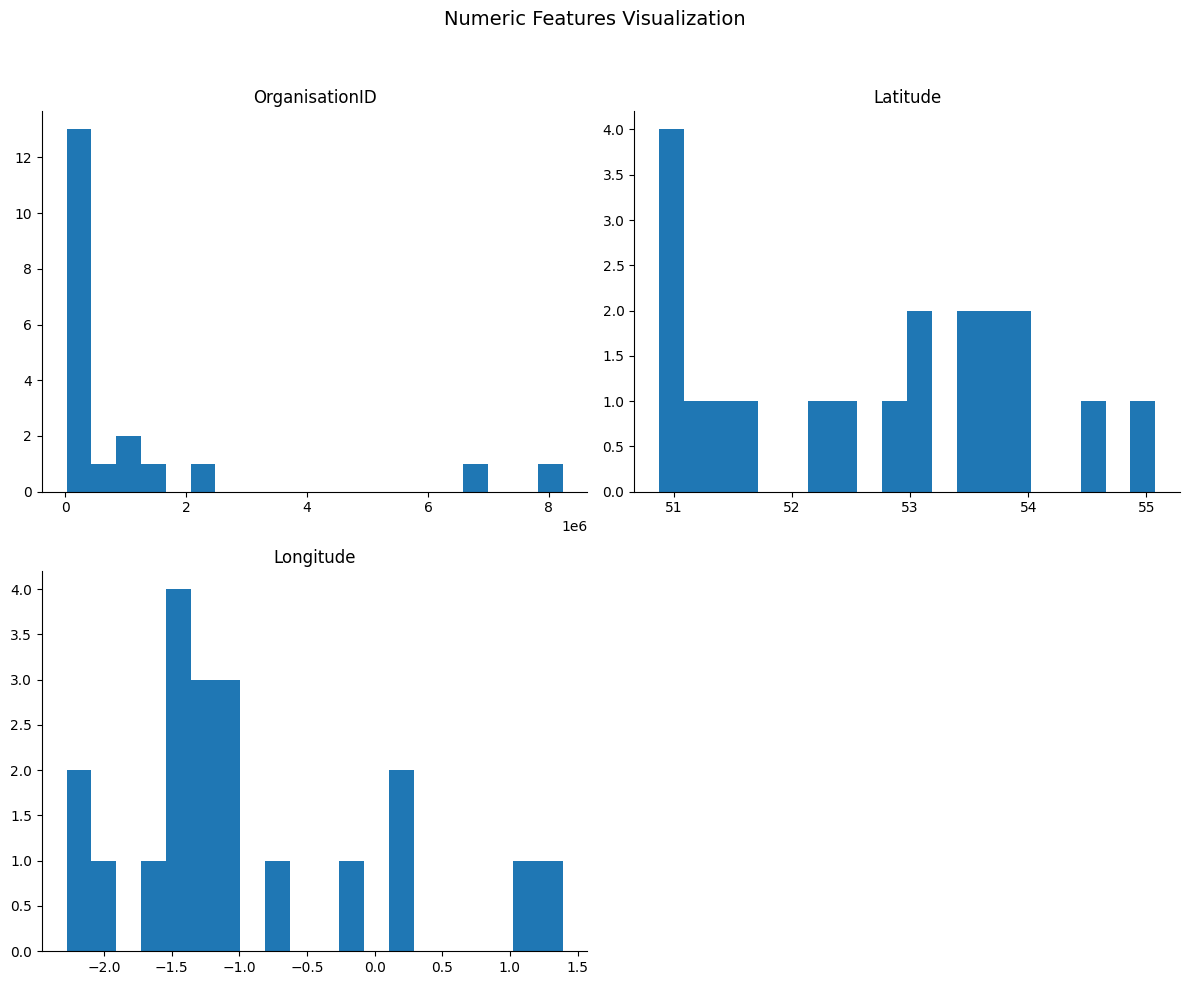

In [12]:
data.hist(figsize=(12,10), bins=20, grid=False)
sns.despine()
plt.suptitle("Numeric Features Visualization", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

### Heat Map for Correlation

<Axes: >

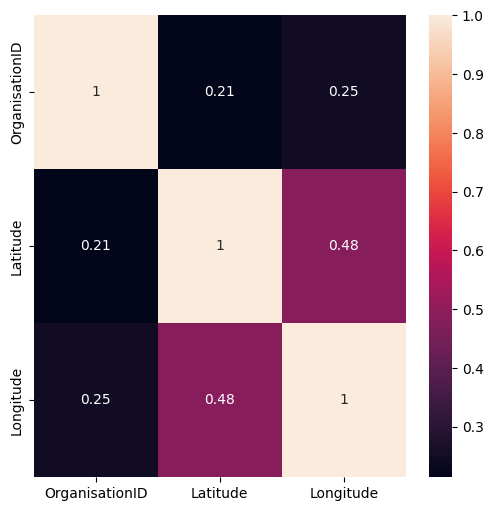

In [21]:
matrix = data.drop(columns=["IsPimsManaged"]).corr(numeric_only=True)
f, ax = plt.subplots(figsize=(6,6))
sns.heatmap(matrix.abs(),annot=True)

CPU times: user 1.05 s, sys: 1.98 s, total: 3.03 s
Wall time: 539 ms


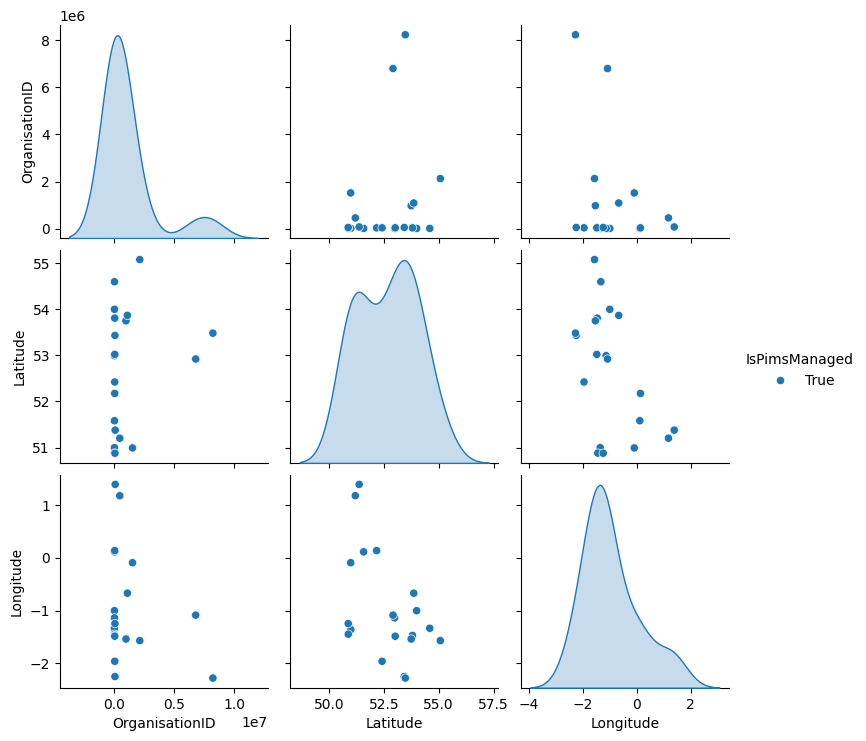

In [24]:
%time sns.pairplot(data, hue="IsPimsManaged", height=2.5)